# Debug: Region Fluorescence ROI Viewer
Step through a CZI file one timestep at a time and inspect every ROI with its computed metric overlaid.

## 1 · Import Required Libraries

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ipywidgets as widgets
from IPython.display import display, clear_output

from aicspylibczi import CziFile

# Make sure the package root is importable when running from notebooks/
sys.path.insert(0, str(Path("../..").resolve()))

from chipanalysis.utils.file_reader import get_pixel_sizes_um, get_frame
from chipanalysis.chip_alignment import align_chip_to_image, get_roi_from_result, ChipGeometry
from chipanalysis.functions.region_fluorescence import profile_mean, count_cells
%load_ext autoreload
%autoreload 2
print("✓ Imports OK")

✓ Imports OK


## 2 · Configure File & Timestep

In [7]:
# ── User config ────────────────────────────────────────────────────────────
# Point this at the folder that contains your .czi files.
CZI_DIR = Path("/Volumes/vangestel/Coco/ZeissData/data_final/AX2+air+bac")

# ROI padding (same defaults as analyze_region_fluorescence.py)
PAD_LEFT_UM   = -500.0
PAD_RIGHT_UM  = -1000.0
PAD_TOP_UM    =  1300.0
PAD_BOTTOM_UM =  1300.0

CHANNELS = [0, 1]
CHANNEL_LABELS = {0: "Ch 0 (DIC)", 1: "Ch 1 (Fluor)"}
# ───────────────────────────────────────────────────────────────────────────

# Discover all .czi files under CZI_DIR
czi_files = sorted(CZI_DIR.rglob("*.czi"))

if not czi_files:
    print(f"⚠  No .czi files found under {CZI_DIR}\n"
          "   → Update CZI_DIR above and re-run this cell.")
else:
    print(f"Found {len(czi_files)} .czi file(s):")
    for f in czi_files:
        print(f"  {f}")

Found 15 .czi file(s):
  /Volumes/vangestel/Coco/ZeissData/data_final/AX2+air+bac/CB1-04_S1.czi
  /Volumes/vangestel/Coco/ZeissData/data_final/AX2+air+bac/CB2-01_S1.czi
  /Volumes/vangestel/Coco/ZeissData/data_final/AX2+air+bac/CB2-01_S2.czi
  /Volumes/vangestel/Coco/ZeissData/data_final/AX2+air+bac/CB2-01_S3.czi
  /Volumes/vangestel/Coco/ZeissData/data_final/AX2+air+bac/CB2-01_S4.czi
  /Volumes/vangestel/Coco/ZeissData/data_final/AX2+air+bac/CB27_init/CB27-01.czi
  /Volumes/vangestel/Coco/ZeissData/data_final/AX2+air+bac/CB27_init/CB27-01_S1.czi
  /Volumes/vangestel/Coco/ZeissData/data_final/AX2+air+bac/CB27_init/CB27-01_S2.czi
  /Volumes/vangestel/Coco/ZeissData/data_final/AX2+air+bac/CB27_slugs/CB27-01.czi
  /Volumes/vangestel/Coco/ZeissData/data_final/AX2+air+bac/CB5-01_S1.czi
  /Volumes/vangestel/Coco/ZeissData/data_final/AX2+air+bac/CB5-01_S3.czi
  /Volumes/vangestel/Coco/ZeissData/data_final/AX2+air+bac/CB7-04_S1.czi
  /Volumes/vangestel/Coco/ZeissData/data_final/AX2+air+bac/CB7

In [8]:
# Widgets – file picker and timestep slider
file_picker = widgets.Dropdown(
    options=[(f.name, f) for f in czi_files] if czi_files else [("(no files found)", None)],
    description="CZI file:",
    layout=widgets.Layout(width="70%"),
    style={"description_width": "80px"},
)

timestep_slider = widgets.IntSlider(
    value=0, min=0, max=0, step=1,
    description="Timestep:",
    continuous_update=False,
    layout=widgets.Layout(width="70%"),
    style={"description_width": "80px"},
)

metric_toggle = widgets.ToggleButtons(
    options=["mean", "cell_count", "both"],
    value="mean",
    description="Metric:",
    style={"description_width": "80px"},
)

status_label = widgets.Label(value="← Select a file then click Load.")

def on_file_change(change):
    """Update the timestep slider range when a new file is chosen."""
    path = change["new"]
    if path is None:
        return
    try:
        _czi = CziFile(path)
        dims   = _czi.dims
        sizes  = _czi.size
        n_t = dict(zip(dims, sizes)).get("T", 1)
        timestep_slider.max   = n_t - 1
        timestep_slider.value = 0
        status_label.value = f"✓ {path.name}  –  {n_t} timepoint(s)"
    except Exception as e:
        status_label.value = f"Error reading file: {e}"

file_picker.observe(on_file_change, names="value")

# Trigger once so the slider range is set for the default selection
if czi_files:
    on_file_change({"new": czi_files[0]})

display(widgets.VBox([file_picker, timestep_slider, metric_toggle, status_label]))

## 3 · Load File & Align Chip
Run this cell whenever you change the selected file.  Alignment is done once on the first frame.

In [9]:
czi_path = file_picker.value
assert czi_path is not None, "No file selected – update CZI_DIR and re-run cell 2."

print(f"Loading: {czi_path}")
czi = CziFile(czi_path)

dim_sizes     = dict(zip(czi.dims, czi.size))
pixel_size_um = get_pixel_sizes_um(czi)
px_um = pixel_size_um["X"]
n_t   = dim_sizes.get("T", 1)

print(f"  Dimensions : {dim_sizes}")
print(f"  Pixel size : {px_um:.4f} µm")
print(f"  Timepoints : {n_t}")

# Align on channel 2 (DIC/phase), first frame
print("Aligning chip to first frame …")
first_frame, _ = get_frame(czi, 0, 2)
align_result = align_chip_to_image(
    first_frame,
    pixel_size_um=px_um,
    debug=False,
    geom=ChipGeometry(),
)
print("  ✓ Alignment done.")

# ── Per-channel intensity normalisation anchors ──────────────────────────
# blob_threshold in count_cells is an *absolute* LoG response value, so it
# is only meaningful if every image is brought onto the same intensity scale
# before the LoG is computed.
#
# We compute two percentile values (p_low = 1st, p_high = 99.5th) from
# the *chip ROI* — the "full" region that covers the extent of all three
# sub-regions (bottom / top / main) — on the first frame of each channel.
# Using the chip ROI rather than the whole frame ensures the background and
# bright-signal references are representative of the actual measurement area
# and are not skewed by surrounding off-chip pixels.
#
#   • p_low  ≈ background level within the chip for this channel
#   • p_high ≈ brightest real signal (cells) within the chip
#
# count_cells then maps [p_low, p_high] → [0, 1] for every ROI crop,
# regardless of how bright or dark that particular crop is.
# ────────────────────────────────────────────────────────────────────────
def _select_full_chip_roi(img):
    """Crop to the full chip extent (encompasses all three sub-regions)."""
    roi, _ = get_roi_from_result(
        align_result,
        align_result["rotate_fn"](img),
        region="full",
        pad_left_um=PAD_LEFT_UM,
        pad_right_um=PAD_RIGHT_UM,
        pad_top_um=PAD_TOP_UM,
        pad_bottom_um=PAD_BOTTOM_UM,
    )
    return roi

print("Computing per-channel normalisation percentiles (chip ROI, first frame) …")
norm_percentiles = {}
for ch in CHANNELS:
    frame, _ = get_frame(czi, 0, ch)
    chip_roi = _select_full_chip_roi(frame)   # crop to chip extent before computing percentiles
    p_low  = np.percentile(chip_roi, 1)       # dark background reference
    p_high = np.percentile(chip_roi, 99.5)    # bright signal reference
    norm_percentiles[ch] = (p_low, p_high)
    print(f"  Ch {ch}: [{p_low:.1f}, {p_high:.1f}]")

Loading: /Volumes/vangestel/Coco/ZeissData/data_final/AX2+air+bac/CB1-04_S1.czi
.//Scaling//Distance[@Id='X']//Value
.//Scaling//Distance[@Id='Y']//Value
  Dimensions : {'S': 1, 'T': 3, 'C': 3, 'M': 2, 'Y': 4512, 'X': 4512}
  Pixel size : 0.9455 µm
  Timepoints : 3
Aligning chip to first frame …
  ✓ Alignment done.
Computing per-channel normalisation percentiles (chip ROI, first frame) …
  Ch 0: [64.5, 173.4]
  Ch 1: [63.8, 163.9]


## 4 · Extract ROIs for the Selected Timestep

In [10]:
ROI_SPECS = [
    # (roi_name,  region,   pad_top_um,   pad_bottom_um)
    ("bottom",  "bottom", -10.0,         PAD_BOTTOM_UM),
    ("top",     "top",    PAD_TOP_UM,    -10.0        ),
    ("main",    "main",   -20.0,         -20.0        ),
]

def extract_rois_for_timestep(t: int, channel: int):
    """Return list of (roi_name, roi_image, coords) for one timestep/channel."""
    img, _ = get_frame(czi, t, channel, gamma=1)
    img_rot = align_result["rotate_fn"](img)

    results = []
    for roi_name, region, pad_top, pad_bottom in ROI_SPECS:
        roi, coords = get_roi_from_result(
            align_result,
            img_rot,
            region=region,
            pad_left_um=PAD_LEFT_UM,
            pad_right_um=PAD_RIGHT_UM,
            pad_top_um=pad_top,
            pad_bottom_um=pad_bottom,
        )
        results.append((roi_name, roi, coords))
    return results


def compute_metrics(roi, channel, metric: str):
    """Return a dict of requested metrics for one ROI."""
    out = {}
    if metric in ("mean", "both"):
        out["mean"] = float(profile_mean(roi, channel))
    if metric in ("cell_count", "both"):
        p_low, p_high = norm_percentiles.get(channel, (None, None))
        out["cell_count"] = int(count_cells(roi, channel, px_um=px_um,
                                            p_low=p_low, p_high=p_high))
    return out


print("Helper functions defined — proceed to cell 5.")

Helper functions defined — proceed to cell 5.


## 5 · Visualise ROIs with Overlaid Metrics
Each column = one ROI region.  Each row = one channel.  The metric value is shown in the title of each panel.

In [11]:
out_area = widgets.Output()

def plot_rois(t: int, metric: str):
    """Render a grid: rows = channels, columns = ROI regions."""
    n_rows = len(CHANNELS)
    n_cols = len(ROI_SPECS)

    fig, axes = plt.subplots(
        n_rows, n_cols,
        figsize=(5 * n_cols, 4 * n_rows),
        squeeze=False,
    )
    fig.suptitle(
        f"{czi_path.name}  –  t = {t}  –  metric: {metric}",
        fontsize=13, fontweight="bold", y=1.01,
    )

    for row_idx, channel in enumerate(CHANNELS):
        roi_data = extract_rois_for_timestep(t, channel)

        for col_idx, (roi_name, roi, coords) in enumerate(roi_data):
            ax = axes[row_idx][col_idx]

            if roi.size == 0:
                ax.set_visible(False)
                continue

            metrics = compute_metrics(roi, channel, metric)

            # Build a concise metric string for the title
            metric_str = "  |  ".join(
                f"{k} = {v:.2f}" if isinstance(v, float) else f"{k} = {v}"
                for k, v in metrics.items()
            )
            p_low, p_high = norm_percentiles.get(channel, (None, None))
            im = ax.imshow(
                roi, cmap="gray", aspect="auto",
                interpolation="nearest",
                vmin=p_low,   # anchor to chip-level percentiles
                vmax=p_high,  # same scale used by count_cells
            )
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

            # Overlay metric value as centred text on the image
            ax.text(
                0.5, 0.05, metric_str,
                transform=ax.transAxes,
                ha="center", va="bottom",
                fontsize=9, color="yellow",
                bbox=dict(boxstyle="round,pad=0.2", fc="black", alpha=0.55),
            )

            ch_label = CHANNEL_LABELS.get(channel, f"Ch {channel}")
            ax.set_title(f"{ch_label}  ·  ROI: {roi_name}", fontsize=10)
            ax.set_xlabel(
                f"x: {coords['x0_px']}–{coords['x1_px']} px  "
                f"y: {coords['y0_px']}–{coords['y1_px']} px",
                fontsize=7,
            )
            ax.set_xticks([])
            ax.set_yticks([])

    plt.tight_layout()
    plt.show()


def on_update(change=None):
    """Callback wired to both widgets."""
    with out_area:
        clear_output(wait=True)
        t      = timestep_slider.value
        metric = metric_toggle.value
        print(f"Rendering t={t}, metric={metric} …")
        plot_rois(t, metric)


# Wire widgets
timestep_slider.observe(on_update, names="value")
metric_toggle.observe(on_update, names="value")

display(widgets.HBox([timestep_slider, metric_toggle]))
display(out_area)

# Initial render
on_update()

Output()

In [20]:
def select_roi(img):
    roi, _ = get_roi_from_result(
    align_result,
    align_result['rotate_fn'](img) ,
    region= "bottom",
    pad_left_um=-1500.0,   # expand chip box leftward (µm)
    pad_right_um=-3000.0,  # expand chip box rightward (µm)
    pad_top_um=-10.0,    # pad above & below main channel centre (symmetric)
    pad_bottom_um= 1000
)
    return roi

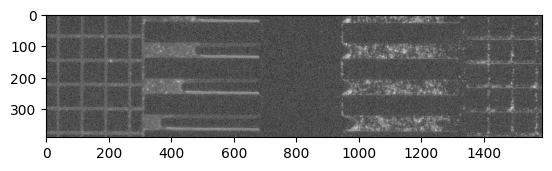

In [15]:
stretch_min = 10
stretch_max = 99.5
channel = 0
time = 0
img, img_disp = get_frame(czi,time,channel,gamma=0.45,stretch_min=stretch_min,stretch_max=stretch_max)
fig,ax = plt.subplots()
ax.imshow(select_roi(img_disp),cmap="gray")

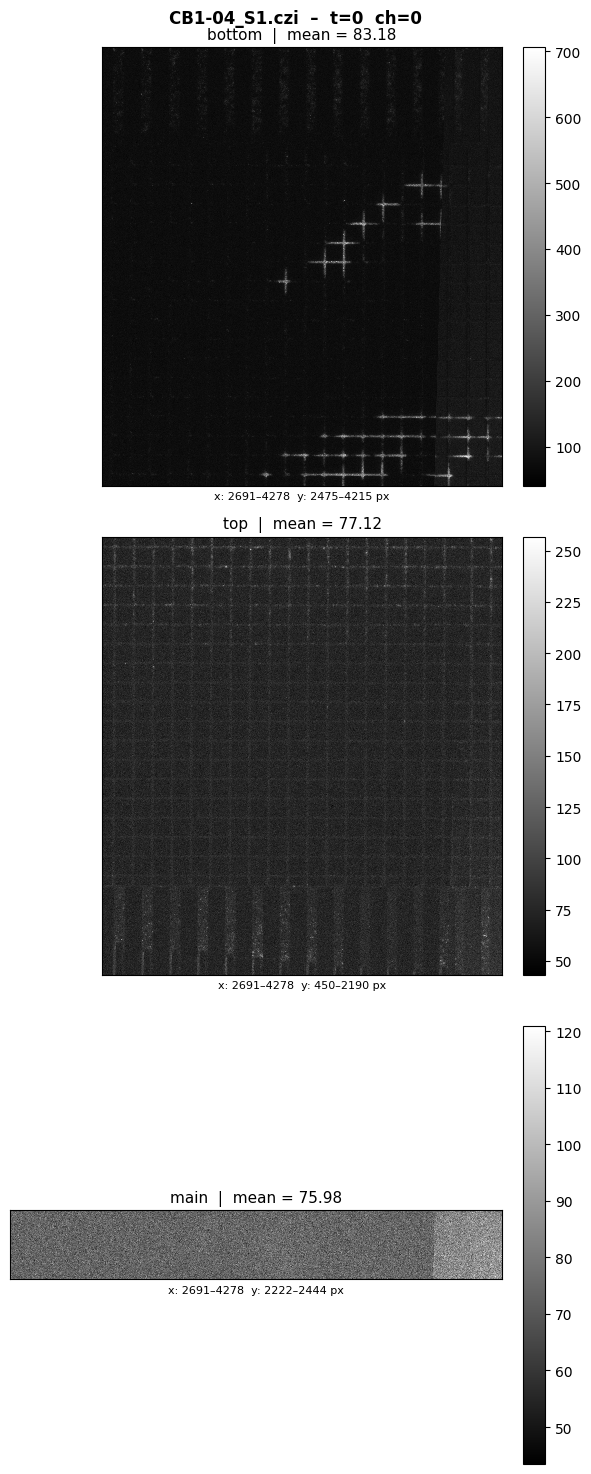

In [21]:
# ── Set these two variables, then run ──────────────────────────────────────
T       = 0   # timestep to inspect
CHANNEL = 0   # channel index
# ───────────────────────────────────────────────────────────────────────────

img, img_disp = get_frame(czi, T, CHANNEL, gamma=1)
img_rot = align_result["rotate_fn"](img)

fig, axes = plt.subplots(len(ROI_SPECS),1, figsize=(6 , 5* len(ROI_SPECS)))
if len(ROI_SPECS) == 1:
    axes = [axes]

for ax, (roi_name, region, pad_top, pad_bottom) in zip(axes, ROI_SPECS):
    roi, coords = get_roi_from_result(
        align_result, img_rot,
        region=region,
        pad_left_um=PAD_LEFT_UM, pad_right_um=PAD_RIGHT_UM,
        pad_top_um=pad_top, pad_bottom_um=pad_bottom,
    )
    metric_val = float(profile_mean(roi, CHANNEL))
    im = ax.imshow(roi, cmap="gray", interpolation="nearest")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_title(f"{roi_name}  |  mean = {metric_val:.2f}", fontsize=11)
    ax.set_xlabel(f"x: {coords['x0_px']}–{coords['x1_px']}  y: {coords['y0_px']}–{coords['y1_px']} px", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

fig.suptitle(f"{czi_path.name}  –  t={T}  ch={CHANNEL}", fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()